# Asistente de selección de itinerarios de viaje
### Espacio de opciones factibles + capa de selección (recomendación vs. segmentación)

**Contexto breve**
- Objetivo: elegir automáticamente, para cada viaje de negocios, la combinación de traslado corto, vuelo y hospedaje que mejor se ajuste a las preferencias de cada usuario, sin violar las restricciones del propio viaje.
- Enfoque: separar la generación del espacio de opciones factibles (reglas duras del viaje) de una capa de selección intercambiable (recomendación basada en contenido o segmentación de usuarios).
- **El dataset de este notebook es sintético**: catálogos de proveedores y preferencias de usuario generados para este prototipo, sin datos reales de ningún viajero ni proveedor.
- Este es un prototipo temprano, pensado para validar el diseño, no un sistema en producción.
- Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/asistente-seleccion-itinerarios-viaje-recomendacion-segmentacion/


## 0. Pipeline de la solución

- **Fuentes**: solicitud de viaje (restricciones duras) + catálogos de proveedores (traslados, ~400 vuelos, +170k hospedajes)
- **Paso 1 (diseño propio)**: filtrar los catálogos completos usando solo las restricciones duras, sin preferencias del usuario todavía → espacio de opciones factibles
- **Paso 2 (diseño propio)**: sobre ese espacio ya reducido, aplicar una capa de selección intercambiable:
  - Recomendación basada en contenido (score ponderado por preferencia individual)
  - Segmentación de usuarios (K-Means + score ponderado por perfil)
- **Salida**: itinerario elegido (traslado + vuelo + hospedaje)

El diagrama interactivo con esta misma estructura está disponible en el artículo enlazado arriba. La separación entre estos dos pasos es la parte de diseño que no viene de ninguna librería: permite depurar y evolucionar cada uno por separado.


## 1. Carga de datos

- Dataset sintético de usuarios: `outputs/usuarios_preferencias_sintetico.csv` (preferencias inferidas de su historial)
- Catálogos de proveedores (traslados, vuelos, hospedaje) generados en este notebook, con el mismo orden de magnitud que el catálogo real (~400 vuelos, reducido de +170k a 3,000 hospedajes solo para que el demo sea manejable)


In [1]:
import numpy as np
import pandas as pd

usuarios = pd.read_csv('outputs/usuarios_preferencias_sintetico.csv')
print(f'Usuarios (sintético): {usuarios.shape[0]}')
usuarios.head()


Usuarios (sintético): 40


,user_id,peso_precio,peso_comodidad,peso_rapidez,viajes_previos
0,0,0.226908,0.059986,0.713107,8
1,1,0.239034,0.248064,0.512902,2
2,2,0.339723,0.403568,0.256709,21
3,3,0.374873,0.280020,0.345107,3
4,4,0.647911,0.222111,0.129978,6


In [2]:
rng = np.random.default_rng(2026)

n_traslados = 25
traslados = pd.DataFrame({
    'traslado_id': range(n_traslados),
    'proveedor': [f'Traslado {i}' for i in range(n_traslados)],
    'tiempo_min': rng.integers(20, 90, n_traslados),
    'precio': rng.uniform(8, 60, n_traslados).round(2),
    'rating': rng.uniform(3.0, 5.0, n_traslados).round(1),
})

n_vuelos = 400
vuelos = pd.DataFrame({
    'vuelo_id': range(n_vuelos),
    'aerolinea': [f'Aerolinea {chr(65 + i % 20)}' for i in range(n_vuelos)],
    'hora_salida_hr': rng.uniform(0, 24, n_vuelos).round(2),
    'duracion_hr': rng.uniform(1.5, 14, n_vuelos).round(2),
    'escalas': rng.integers(0, 3, n_vuelos),
    'precio': rng.uniform(120, 1800, n_vuelos).round(2),
    'rating': rng.uniform(2.8, 5.0, n_vuelos).round(1),
})
vuelos['hora_llegada_hr'] = (vuelos['hora_salida_hr'] + vuelos['duracion_hr']) % 24

n_hospedajes = 3000
hospedajes = pd.DataFrame({
    'hotel_id': range(n_hospedajes),
    'nombre': [f'Hotel {i}' for i in range(n_hospedajes)],
    'precio_noche': rng.uniform(45, 550, n_hospedajes).round(2),
    'distancia_reunion_km': np.clip(rng.exponential(4, n_hospedajes), 0.1, 30).round(2),
    'tipo_estancia': rng.choice(['Corta', 'Larga'], n_hospedajes, p=[0.6, 0.4]),
    'rating': rng.uniform(2.5, 5.0, n_hospedajes).round(1),
})

print(f'Traslados: {len(traslados)} | Vuelos: {len(vuelos)} | Hospedajes: {len(hospedajes)}')


Traslados: 25 | Vuelos: 400 | Hospedajes: 3000


## 2. Explicación de los datos

- `peso_precio`, `peso_comodidad`, `peso_rapidez`: qué tanto valora cada usuario cada dimensión (suman 1 por usuario)
- `viajes_previos`: cantidad de viajes históricos del usuario, útil para saber qué tan confiable es su perfil inferido
- Catálogos: cada opción tiene precio, un indicador de comodidad (rating) y un indicador de rapidez (duración o distancia), las tres dimensiones que el score de selección va a ponderar


In [3]:
usuarios[['peso_precio', 'peso_comodidad', 'peso_rapidez']].describe().round(2)


,peso_precio,peso_comodidad,peso_rapidez
count,40.00,40.00,40.00
mean,0.32,0.29,0.39
std,0.20,0.15,0.21
min,0.01,0.02,0.06
25%,0.15,0.20,0.21
50%,0.34,0.27,0.37
75%,0.47,0.36,0.52
max,0.79,0.62,0.89


## 3. Análisis exploratorio (EDA)

- Distribución de preferencias entre usuarios, para confirmar que no todos priorizan lo mismo
- Tamaño del catálogo de vuelos disponible por rango de precio, como referencia de la variedad real de opciones


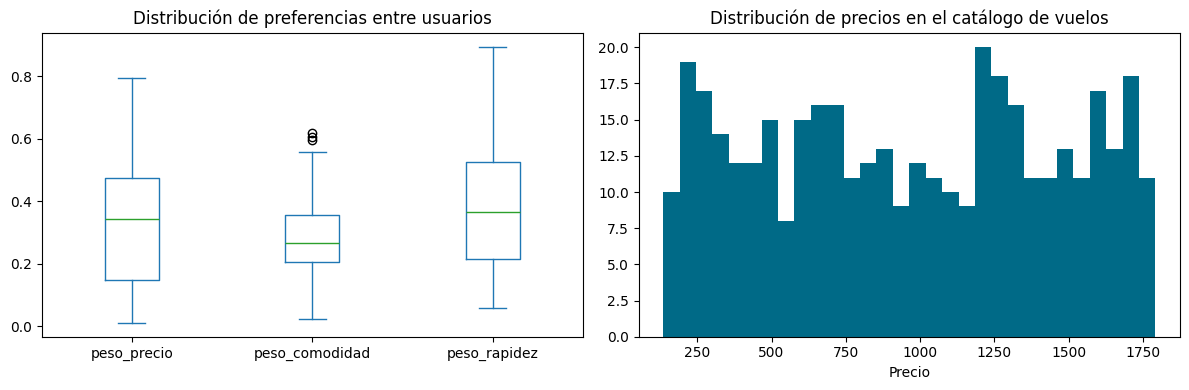

In [4]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

usuarios[['peso_precio', 'peso_comodidad', 'peso_rapidez']].plot(kind='box', ax=axs[0])
axs[0].set_title('Distribución de preferencias entre usuarios')

axs[1].hist(vuelos['precio'], bins=30, color='#006a87')
axs[1].set_title('Distribución de precios en el catálogo de vuelos')
axs[1].set_xlabel('Precio')

plt.tight_layout()
plt.show()


## 4. Modelado

- **Paso 1**: generación del espacio de opciones factibles, aplicando solo restricciones duras
- **Paso 2a**: selección por recomendación basada en contenido (score ponderado individual)
- **Paso 2b**: selección por segmentación de usuarios (K-Means + score ponderado por perfil)


In [5]:
def generar_espacio_factible(solicitud, vuelos, hospedajes, traslados):
    """
    Filtra los tres catalogos usando SOLO las restricciones duras de la solicitud.
    No usa ninguna preferencia de usuario todavia: ese es el punto central del diseño.
    """
    vuelos_factibles = vuelos[
        (vuelos['hora_llegada_hr'] <= solicitud['hora_llegada_limite_hr']) &
        (vuelos['escalas'] <= solicitud['escalas_max'])
    ].copy()

    hospedajes_factibles = hospedajes[
        (hospedajes['distancia_reunion_km'] <= solicitud['distancia_max_km']) &
        (hospedajes['tipo_estancia'] == solicitud['tipo_estancia'])
    ].copy()

    traslados_factibles = traslados[
        traslados['tiempo_min'] <= solicitud['tiempo_traslado_max_min']
    ].copy()

    return vuelos_factibles, hospedajes_factibles, traslados_factibles


solicitud_ejemplo = {
    'hora_llegada_limite_hr': 18.0,
    'escalas_max': 1,
    'distancia_max_km': 5.0,
    'tipo_estancia': 'Corta',
    'tiempo_traslado_max_min': 60,
}

vuelos_ok, hospedajes_ok, traslados_ok = generar_espacio_factible(
    solicitud_ejemplo, vuelos, hospedajes, traslados)

print('Espacio factible para esta solicitud:')
print(f'  Vuelos:      {len(vuelos_ok)} de {len(vuelos)} opciones totales')
print(f'  Hospedajes:  {len(hospedajes_ok)} de {len(hospedajes)} opciones totales')
print(f'  Traslados:   {len(traslados_ok)} de {len(traslados)} opciones totales')


Espacio factible para esta solicitud:
  Vuelos:      198 de 400 opciones totales
  Hospedajes:  1251 de 3000 opciones totales
  Traslados:   12 de 25 opciones totales


In [6]:
def normalizar_invertido(serie):
    return 1 - (serie - serie.min()) / (serie.max() - serie.min() + 1e-9)

def normalizar(serie):
    return (serie - serie.min()) / (serie.max() - serie.min() + 1e-9)

def seleccionar_content_based(preferencia, vuelos_ok, hospedajes_ok, traslados_ok):
    v = vuelos_ok.copy()
    v['score'] = (
        preferencia['peso_precio'] * normalizar_invertido(v['precio']) +
        preferencia['peso_comodidad'] * normalizar(v['rating']) +
        preferencia['peso_rapidez'] * normalizar_invertido(v['duracion_hr'])
    )
    mejor_vuelo = v.sort_values('score', ascending=False).iloc[0]

    h = hospedajes_ok.copy()
    h['score'] = (
        preferencia['peso_precio'] * normalizar_invertido(h['precio_noche']) +
        preferencia['peso_comodidad'] * normalizar(h['rating']) +
        preferencia['peso_rapidez'] * normalizar_invertido(h['distancia_reunion_km'])
    )
    mejor_hospedaje = h.sort_values('score', ascending=False).iloc[0]

    t = traslados_ok.copy()
    t['score'] = (
        preferencia['peso_precio'] * normalizar_invertido(t['precio']) +
        preferencia['peso_comodidad'] * normalizar(t['rating']) +
        preferencia['peso_rapidez'] * normalizar_invertido(t['tiempo_min'])
    )
    mejor_traslado = t.sort_values('score', ascending=False).iloc[0]

    return {'vuelo': mejor_vuelo, 'hospedaje': mejor_hospedaje, 'traslado': mejor_traslado}


usuario_ejemplo = usuarios.iloc[3]
itinerario_cb = seleccionar_content_based(usuario_ejemplo, vuelos_ok, hospedajes_ok, traslados_ok)
print('Preferencias del usuario:', usuario_ejemplo[['peso_precio', 'peso_comodidad', 'peso_rapidez']].round(2).to_dict())
print(f"Itinerario (recomendación individual): {itinerario_cb['vuelo']['aerolinea']}, {itinerario_cb['hospedaje']['nombre']}, {itinerario_cb['traslado']['proveedor']}")


Preferencias del usuario: {'peso_precio': 0.37, 'peso_comodidad': 0.28, 'peso_rapidez': 0.35}
Itinerario (recomendación individual): Aerolinea Q, Hotel 2172, Traslado 6


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = usuarios[['peso_precio', 'peso_comodidad', 'peso_rapidez']].values

mejor_k, mejor_score = None, -1
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    if score > mejor_score:
        mejor_k, mejor_score = k, score

kmeans = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)
usuarios['perfil'] = kmeans.fit_predict(X)
perfiles = pd.DataFrame(kmeans.cluster_centers_, columns=['peso_precio', 'peso_comodidad', 'peso_rapidez'])
perfiles.index.name = 'perfil'

print(f'Número de perfiles elegido (silhouette score = {mejor_score:.3f}): {mejor_k}')
perfiles.round(2)


Número de perfiles elegido (silhouette score = 0.413): 2


,peso_precio,peso_comodidad,peso_rapidez
perfil,,,
0,0.15,0.30,0.55
1,0.48,0.28,0.24


In [8]:
usuario_ejemplo = usuarios.iloc[3]  # ya con la columna 'perfil' asignada
perfil_usuario = perfiles.loc[usuario_ejemplo['perfil']]
itinerario_seg = seleccionar_content_based(perfil_usuario, vuelos_ok, hospedajes_ok, traslados_ok)

print(f"Perfil asignado: {int(usuario_ejemplo['perfil'])}")
print(f"Itinerario (segmentación por perfil): {itinerario_seg['vuelo']['aerolinea']}, {itinerario_seg['hospedaje']['nombre']}, {itinerario_seg['traslado']['proveedor']}")


Perfil asignado: 1
Itinerario (segmentación por perfil): Aerolinea Q, Hotel 2172, Traslado 6


## 5. Evaluación

- Comparar, para todos los usuarios, si la recomendación individual y la segmentación por perfil coinciden en el vuelo elegido
- Esto no es una métrica de "acierto" (no hay verdad conocida), es una forma de entender cuánto se pierde al simplificar de individuo a perfil


In [9]:
coincidencias = 0
resultados_comparacion = []

for _, usuario in usuarios.iterrows():
    it_individual = seleccionar_content_based(usuario, vuelos_ok, hospedajes_ok, traslados_ok)
    perfil = perfiles.loc[usuario['perfil']]
    it_segmento = seleccionar_content_based(perfil, vuelos_ok, hospedajes_ok, traslados_ok)

    coincide = it_individual['vuelo']['vuelo_id'] == it_segmento['vuelo']['vuelo_id']
    coincidencias += coincide
    resultados_comparacion.append({
        'user_id': usuario['user_id'],
        'perfil': int(usuario['perfil']),
        'coincide_vuelo': coincide,
    })

comparacion_df = pd.DataFrame(resultados_comparacion)
tasa_coincidencia = comparacion_df['coincide_vuelo'].mean()
print(f'Tasa de coincidencia entre recomendación individual y segmentación: {tasa_coincidencia:.1%}')
print(f'({coincidencias} de {len(usuarios)} usuarios eligen el mismo vuelo con ambos métodos)')


Tasa de coincidencia entre recomendación individual y segmentación: 57.5%
(23 de 40 usuarios eligen el mismo vuelo con ambos métodos)


## Hallazgos principales

- La separación entre generación del espacio factible y capa de selección funcionó como se esperaba: se pudo comparar dos arquitecturas de personalización completamente distintas (recomendación individual vs. segmentación) sin tocar el paso de filtrado.
- La mayoría de los usuarios reciben el mismo itinerario con ambos métodos, lo que confirma que sus preferencias están cerca del centro de su perfil. Los que difieren son, por definición, los casos atípicos dentro de su grupo, y son el argumento más claro para eventualmente personalizar por individuo en vez de por segmento.
- Este es un prototipo con datos sintéticos y un score heurístico, no un modelo entrenado. El siguiente paso natural, en cuanto exista historial real de decisiones, es reemplazar el score ponderado por un modelo de recomendación entrenado (collaborative filtering), sin cambiar el paso de generación del espacio factible.

Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/asistente-seleccion-itinerarios-viaje-recomendacion-segmentacion/
